In [2]:
# M7.2 -- Plotting multiple groups on the same chart
# Combining .groupby() with .unstack()

# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# create the dataframe
df = pd.DataFrame({
    "month":    ["Jan","Feb","Mar","Apr","May","Jun"] * 3,
    "supplier": ["Acme"]*6 + ["GlobalCo"]*6 + ["FastParts"]*6,
    "spend":    [1500,1800,1200,2100,1700,2000,
                 2200,1900,2400,2000,2300,2100,
                 800,950,1100,750,900,1050],
    "otd_rate": [80,90,70,100,90,100,
                 90,80,100,90,100,90,
                 70,80,90,70,80,90]
})

# order the months using pd.Categorical
month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
df["month"] = pd.Categorical(values=df["month"],
                             categories=month_order,
                             ordered=True)

# view
print(df)

   month   supplier  spend  otd_rate
0    Jan       Acme   1500        80
1    Feb       Acme   1800        90
2    Mar       Acme   1200        70
3    Apr       Acme   2100       100
4    May       Acme   1700        90
5    Jun       Acme   2000       100
6    Jan   GlobalCo   2200        90
7    Feb   GlobalCo   1900        80
8    Mar   GlobalCo   2400       100
9    Apr   GlobalCo   2000        90
10   May   GlobalCo   2300       100
11   Jun   GlobalCo   2100        90
12   Jan  FastParts    800        70
13   Feb  FastParts    950        80
14   Mar  FastParts   1100        90
15   Apr  FastParts    750        70
16   May  FastParts    900        80
17   Jun  FastParts   1050        90


supplier  Acme  FastParts  GlobalCo
month                              
Jan       1500        800      2200
Feb       1800        950      1900
Mar       1200       1100      2400
Apr       2100        750      2000
May       1700        900      2300
Jun       2000       1050      2100
month  supplier 
Jan    Acme         1500
       FastParts     800
       GlobalCo     2200
Feb    Acme         1800
       FastParts     950
       GlobalCo     1900
Mar    Acme         1200
       FastParts    1100
       GlobalCo     2400
Apr    Acme         2100
       FastParts     750
       GlobalCo     2000
May    Acme         1700
       FastParts     900
       GlobalCo     2300
Jun    Acme         2000
       FastParts    1050
       GlobalCo     2100
Name: spend, dtype: int64


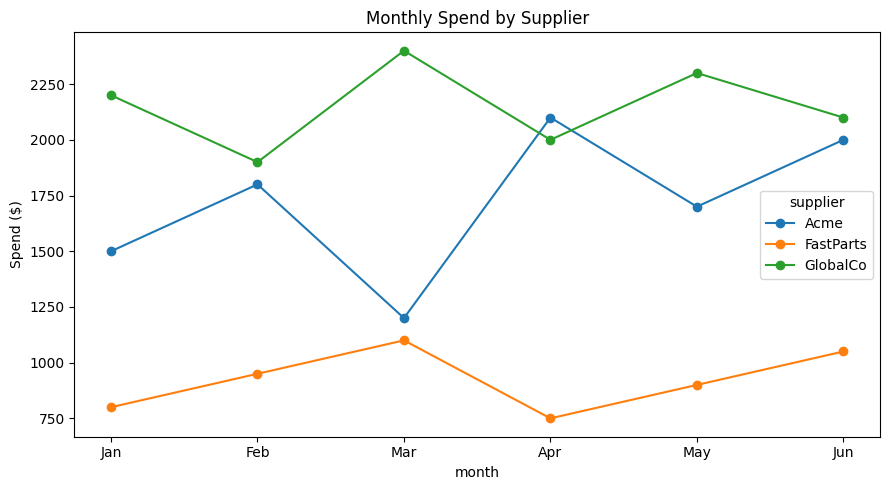

In [3]:
# Exercise 2 -- Multiline Chart w/One Line per Supplier
spend_by_supplier = (
    df
    .groupby(by=["month", "supplier"])["spend"]
    .sum()
    .unstack("supplier")
)

# view spend by supplier
print(spend_by_supplier)

# view without .unstack()
spend_by_supplier_no = (
    df
    .groupby(by=["month", "supplier"])["spend"]
    .sum()
)
# view without supplier column .unstack()
print(spend_by_supplier_no)


# build your plot using the .unstack() data
spend_by_supplier.plot(
    kind="line",
    title="Monthly Spend by Supplier",
    figsize=(9,5),
    marker="o"
)
plt.ylabel("Spend ($)")
plt.tight_layout()
plt.show()

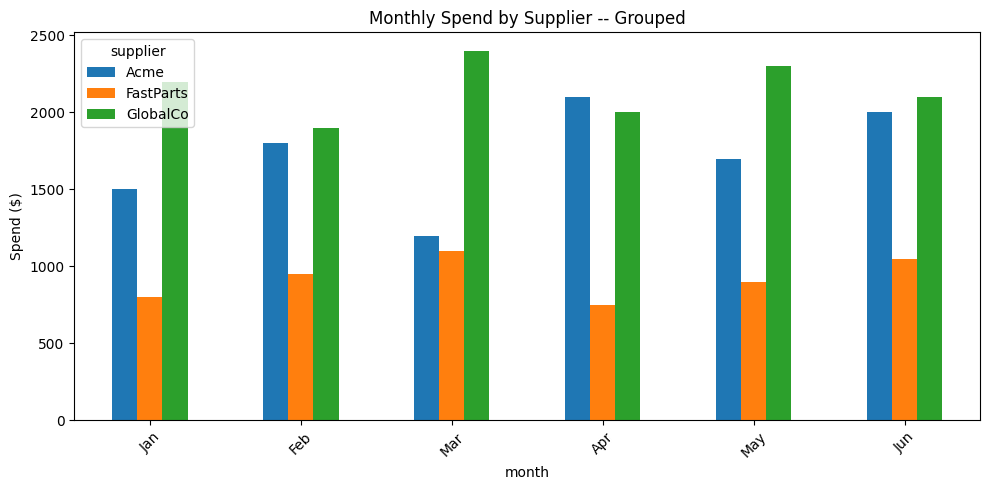

In [4]:
# Exercise 3 -- Grouped Bar Chart
# Plot the previous supplier_spend_data as a grouped bar chart

spend_by_supplier.plot(
    kind="bar",
    title="Monthly Spend by Supplier -- Grouped",
    figsize=(10,5)
)
plt.ylabel("Spend ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

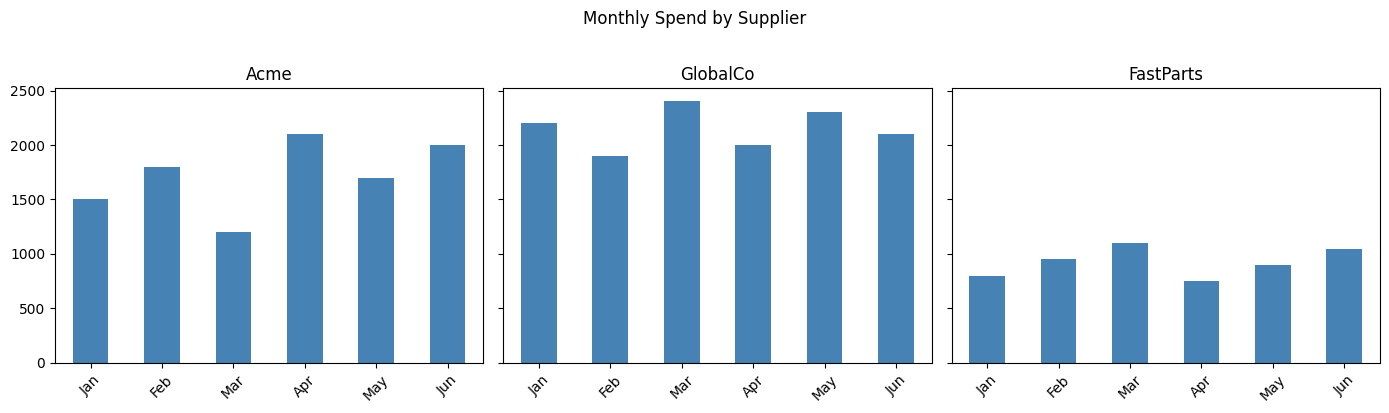

In [ ]:
# Exercise 4 -- Subplots with one chart per supplier

# use a for-loop to demonstrate the DRY concept
# Do not repeat yourself
# the loop iterates over a list and applies the same logic to each supplier
# you can add/remove suppliers down the road

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for idx, supplier in enumerate(["Acme", "GlobalCo", "FastParts"]):
    supplier_df = (
        df[df["supplier"] == supplier]
        .set_index("month")
    )
    supplier_df["spend"].plot(
        ax=axes[idx],
        kind="bar",
        title=supplier,
        color="steelblue"
    )
    axes[idx].set_xlabel("")
    axes[idx].tick_params(axis="x", rotation=45)

plt.suptitle("Monthly Spend by Supplier", y=1.02)
plt.tight_layout()
plt.show()

